In [2]:
pip install kagglehub

  Using cached kagglehub-0.3.13-py3-none-any.whl.metadata (38 kB)
Using cached kagglehub-0.3.13-py3-none-any.whl (68 kB)
Note: you may need to restart the kernel to use updated packages.


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

100%|██████████| 66.0M/66.0M [00:08<00:00, 8.34MB/s]

Extracting files...


Path to dataset files: /Users/anshparmar/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3


In [4]:
import os
import pandas as pd

# Path returned by kagglehub
folder = path  

# Build the full CSV path
csv_path = os.path.join(folder, "creditcard.csv")

# Load the data
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
df.head()


Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
csv_path = os.path.join(path, "creditcard.csv")


In [6]:
# Cell 4: Imports and configuration for the Autoencoder + XGBoost pipeline
import os, glob, math, joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, precision_recall_fscore_support, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns


# Deep Learning backend
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers


# XGBoost
import xgboost as xgb

In [8]:
# Cell 5: Load dataset (pipeline uses csv_path from Cell 3)
if not os.path.exists(csv_path):
  raise FileNotFoundError(f"CSV not found at {csv_path}. Make sure Cell 1 ran and the path is correct.")


print("Loading dataset from:", csv_path)
df = pd.read_csv(csv_path)
print("Loaded shape:", df.shape)


df_orig = df.copy()

Loading dataset from: /Users/anshparmar/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3/creditcard.csv
Loaded shape: (284807, 31)


In [9]:
# Cell 6: Preprocessing
# Detect label column and prepare features
label_col = None
for c in ['Class','isFraud','fraud','label','is_fraud']:
    if c in df.columns:
        label_col = c
        break

if label_col:
    print("Detected label column:", label_col)
    y = df[label_col].astype(int).copy()
    X_full = df.drop(columns=[label_col])
else:
    print("No label detected. We'll run autoencoder unsupervised and still produce reconstruction scores.")
    y = None
    X_full = df.copy()

# Time feature engineering for Kaggle dataset
if 'Time' in X_full.columns:
    try:
        X_full['hour'] = (X_full['Time'] // 3600) % 24
    except Exception:
        pass
    X_full = X_full.drop(columns=['Time'])

# Categorical handling (low-cardinality)
cat_cols = [c for c in X_full.columns if X_full[c].dtype == 'object' or X_full[c].nunique() < 50]
cat_cols = [c for c in cat_cols if X_full[c].nunique() < 200]
if len(cat_cols) > 0:
    X_full = pd.get_dummies(X_full, columns=cat_cols, drop_first=True)

# Fill numeric NaNs
num_cols = X_full.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols:
    X_full[c] = X_full[c].fillna(X_full[c].median())

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full.values)
print("Feature matrix shape:", X_scaled.shape)

Detected label column: Class
Feature matrix shape: (284807, 52)


In [10]:
# Cell 7: Prepare training data for Autoencoder
if y is not None:
    normal_idx = np.where(y == 0)[0]
    X_train_full = X_scaled[normal_idx]
    X_train, X_val = train_test_split(X_train_full, test_size=0.2, random_state=42)
    X_test = X_scaled
    y_test = y.values
    print("Training autoencoder on normal transactions only. #normals:", X_train_full.shape[0])
else:
    X_train, X_val = train_test_split(X_scaled, test_size=0.2, random_state=42)
    X_test = X_scaled
    y_test = None

Training autoencoder on normal transactions only. #normals: 284315


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 52)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        13,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 13)             │           845 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 52)             │        13,364 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,169 (434.25 KB)

 Trainable params: 111,169 (434.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
889/889 - 3s - 4ms/step - loss: 0.3155 - val_loss: 0.1905
Epoch 2/100
889/889 - 3s - 3ms/step - loss: 0.1636 - val_loss: 0.1358
Epoch 3/100
889/889 - 2s - 3ms/step - loss: 0.1259 - val_loss: 0.1114
Epoch 4/100
889/889 - 3s - 3ms/step - loss: 0.1039 - val_loss: 0.0974
Epoch 5/100
889/889 - 2s - 3ms/step - loss: 0.0920 - val_loss: 0.0921
Epoch 6/100
889/889 - 3s - 3ms/step - loss: 0.0820 - val_loss: 0.0868
Epoch 7/100
889/889 - 3s - 3ms/step - loss: 0.0745 - val_loss: 0.0700
Epoch 8/100
889/889 - 3s - 3ms/step - loss: 0.0692 - val_loss: 0.0658
Epoch 9/100
889/889 - 3s - 3ms/step - loss: 0.0640 - val_loss: 0.0706
Epoch 10/100
889/889 - 3s - 3ms/step - loss: 0.0603 - val_loss: 0.0610
Epoch 11/100
889/889 - 3s - 3ms/step - loss: 0.0565 - val_loss: 0.0616
Epoch 12/100
889/889 - 3s - 3ms/step - loss: 0.0543 - val_loss: 0.0529
Epoch 13/100
889/889 - 3s - 3ms/step - loss: 0.0506 - val_loss: 0.0493
Epoch 14/100
889/889 - 3s - 3ms/step - loss: 0.0507 - val_loss: 0.0463
Epoch 15/100
88

Saved autoencoder_model.h5 and scaler.save


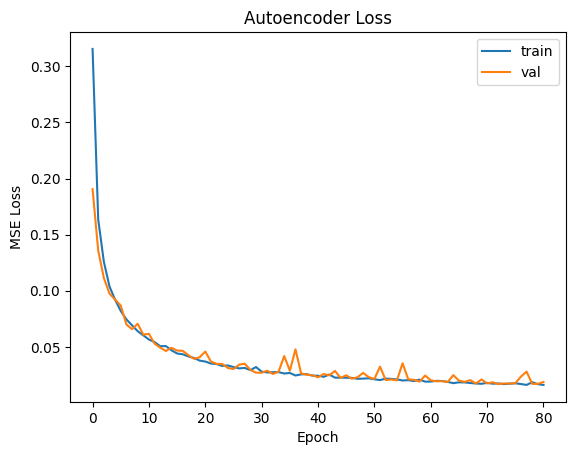

In [11]:
# Cell 8: Build and train Autoencoder
input_dim = X_train.shape[1]
encoding_dim = max(8, input_dim // 4)

def build_autoencoder(input_dim, encoding_dim):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(max(256, input_dim), activation='relu')(inp)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    encoded = layers.Dense(encoding_dim, activation='relu', name='bottleneck')(x)
    x = layers.Dense(64, activation='relu')(encoded)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(max(256, input_dim), activation='relu')(x)
    out = layers.Dense(input_dim, activation='linear')(x)
    autoenc = models.Model(inputs=inp, outputs=out)
    autoenc.compile(optimizer='adam', loss='mse')
    return autoenc

autoenc = build_autoencoder(input_dim, encoding_dim)
autoenc.summary()

es = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
history = autoenc.fit(
    X_train, X_train,
    epochs=100,
    batch_size=256,
    validation_data=(X_val, X_val),
    callbacks=[es],
    verbose=2
)

# Save model & scaler
autoenc.save('autoencoder_model.h5')
joblib.dump(scaler, 'scaler.save')
print("Saved autoencoder_model.h5 and scaler.save")

# Plot loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Autoencoder Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend(['train', 'val'])
plt.show()



8901/8901 ━━━━━━━━━━━━━━━━━━━━ 4s 398us/step
Reconstruction error computed. Example MSE: [0.01129802 0.00163655 0.03100792 0.00673787 0.01742328]
AUC using reconstruction error alone: 0.9486
7108/7108 ━━━━━━━━━━━━━━━━━━━━ 3s 390us/step
Threshold (mean + 3*std on train normals): 0.16898816217870416
Recon-only detector -> precision: 0.10712401055408971 recall: 0.8252032520325203 f1: 0.1896310135450724
Confusion matrix (recon-only):
 [[280931   3384]
 [    86    406]]


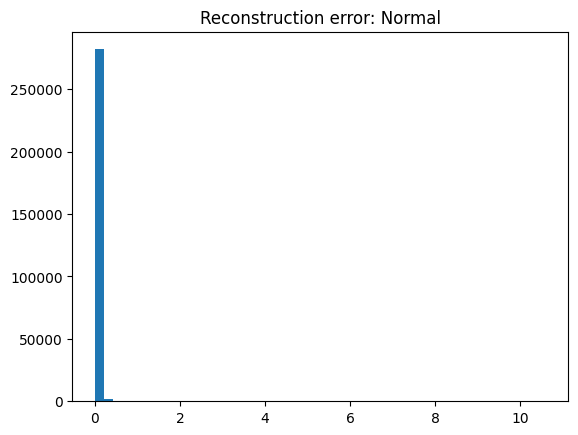

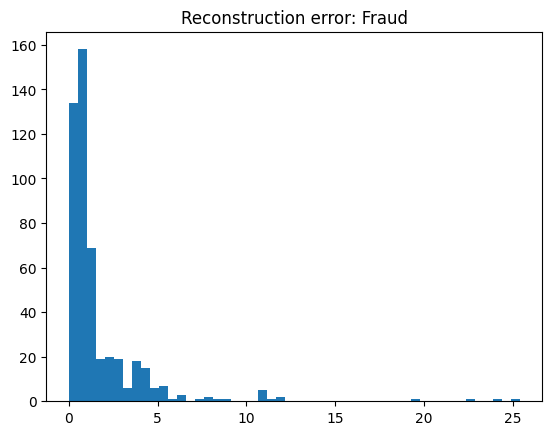

In [12]:
# Cell 9: Reconstruction error and basic evaluation
X_test_pred = autoenc.predict(X_test)
mse = np.mean(np.square(X_test - X_test_pred), axis=1)
print("Reconstruction error computed. Example MSE:", mse[:5])

df_with_scores = df_orig.copy()
df_with_scores['recon_error'] = mse

if y_test is not None:
    auc_score = roc_auc_score(y_test, mse)
    print(f"AUC using reconstruction error alone: {auc_score:.4f}")
    train_pred = autoenc.predict(X_train)
    train_mse = np.mean(np.square(X_train - train_pred), axis=1)
    thr = train_mse.mean() + 3 * train_mse.std()
    print("Threshold (mean + 3*std on train normals):", thr)
    y_pred_re = (mse > thr).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_re, average='binary', zero_division=0)
    print("Recon-only detector -> precision:", precision, "recall:", recall, "f1:", f1)
    print("Confusion matrix (recon-only):\n", confusion_matrix(y_test, y_pred_re))
    plt.figure()
    plt.hist(mse[y_test==0], bins=50)
    plt.title('Reconstruction error: Normal')
    plt.show()
    plt.figure()
    plt.hist(mse[y_test==1], bins=50)
    plt.title('Reconstruction error: Fraud')
    plt.show()



In [13]:
# Cell 10: Prepare features for XGBoost and train (supervised)
X_for_xgb = np.hstack([X_scaled, mse.reshape(-1,1)])
print("X_for_xgb shape:", X_for_xgb.shape)

if y_test is None:
    top_idx = np.argsort(mse)[-20:][::-1]
    print("Top anomalous transactions indices (unsupervised):", top_idx[:20])
    display(df_with_scores.iloc[top_idx].head(20))
    raise SystemExit("No labels present — XGBoost training skipped. Provide labeled CSV to continue supervised training.")

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X_for_xgb, y_test, test_size=0.2, stratify=y_test, random_state=42)

# XGBoost DMatrix
dtrain = xgb.DMatrix(X_train_xgb, label=y_train_xgb)
dtest = xgb.DMatrix(X_test_xgb, label=y_test_xgb)

params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'learning_rate': 0.1,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42,
    'verbosity': 1
}

evallist = [(dtrain, 'train'), (dtest, 'eval')]
num_round = 200

bst = xgb.train(params, dtrain, num_round, evallist, early_stopping_rounds=20)
bst.save_model('xgb_model.json')
print("Saved xgb_model.json")



X_for_xgb shape: (284807, 53)
[0]	train-auc:0.96839	eval-auc:0.96055
[1]	train-auc:0.97456	eval-auc:0.96185
[2]	train-auc:0.97824	eval-auc:0.96030
[3]	train-auc:0.98627	eval-auc:0.96546
[4]	train-auc:0.98736	eval-auc:0.97173


/Users/anshparmar/Documents/JN/anaconda3/envs/nnlab/lib/python3.11/site-packages/xgboost/core.py:771: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


[5]	train-auc:0.98721	eval-auc:0.97019
[6]	train-auc:0.99019	eval-auc:0.97274
[7]	train-auc:0.99099	eval-auc:0.96503
[8]	train-auc:0.99176	eval-auc:0.97256
[9]	train-auc:0.99183	eval-auc:0.97500
[10]	train-auc:0.99195	eval-auc:0.97494
[11]	train-auc:0.99406	eval-auc:0.97551
[12]	train-auc:0.99412	eval-auc:0.97560
[13]	train-auc:0.99425	eval-auc:0.97496
[14]	train-auc:0.99470	eval-auc:0.97389
[15]	train-auc:0.99632	eval-auc:0.97306
[16]	train-auc:0.99716	eval-auc:0.97355
[17]	train-auc:0.99783	eval-auc:0.97408
[18]	train-auc:0.99803	eval-auc:0.97303
[19]	train-auc:0.99812	eval-auc:0.97681
[20]	train-auc:0.99827	eval-auc:0.97819
[21]	train-auc:0.99836	eval-auc:0.97853
[22]	train-auc:0.99861	eval-auc:0.97787
[23]	train-auc:0.99876	eval-auc:0.97729
[24]	train-auc:0.99893	eval-auc:0.97653
[25]	train-auc:0.99902	eval-auc:0.97620
[26]	train-auc:0.99912	eval-auc:0.97587
[27]	train-auc:0.99918	eval-auc:0.97548
[28]	train-auc:0.99918	eval-auc:0.97506
[29]	train-auc:0.99929	eval-auc:0.97446
[30]	

XGBoost AUC on test: 0.9765526304078187
Classification report (XGBoost):
              precision    recall  f1-score   support

           0     0.9997    0.9998    0.9998     56864
           1     0.9000    0.8265    0.8617        98

    accuracy                         0.9995     56962
   macro avg     0.9499    0.9132    0.9307     56962
weighted avg     0.9995    0.9995    0.9995     56962



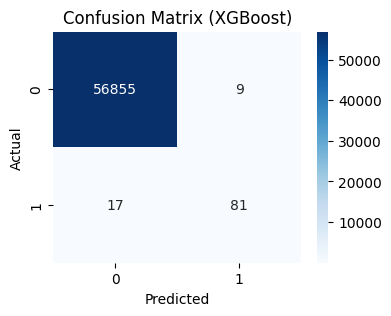

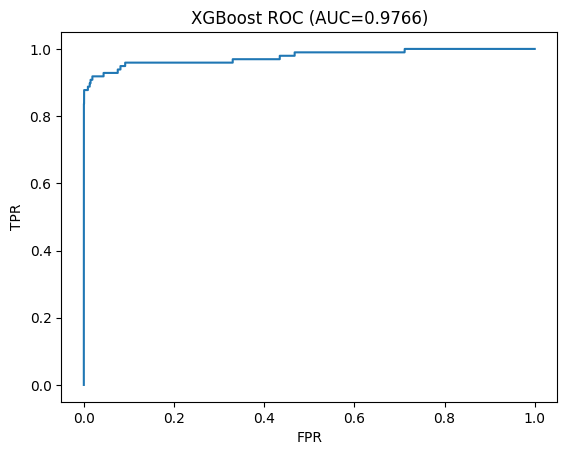

Top features by gain:
         feature         gain
36  recon_error  1826.382446
11          V12   263.395172
13          V14    13.922663
3            V4    13.760340
1            V2    12.340247
16          V17    11.281092
9           V10     9.257164
10          V11     8.239100
12          V13     7.678162
2            V3     7.607082
7            V8     6.922346
27          V28     6.664129
19          V20     6.623767
26          V27     6.612259
0            V1     6.410824
6            V7     6.247472
5            V6     5.814060
18          V19     5.779913
28       Amount     5.359608
14          V15     5.337986
22          V23     5.244547
17          V18     4.896739
24          V25     4.762878
20          V21     4.670229
15          V16     4.503094
25          V26     4.323133
21          V22     4.244855
4            V5     3.994122
8            V9     3.737749
23          V24     3.665185


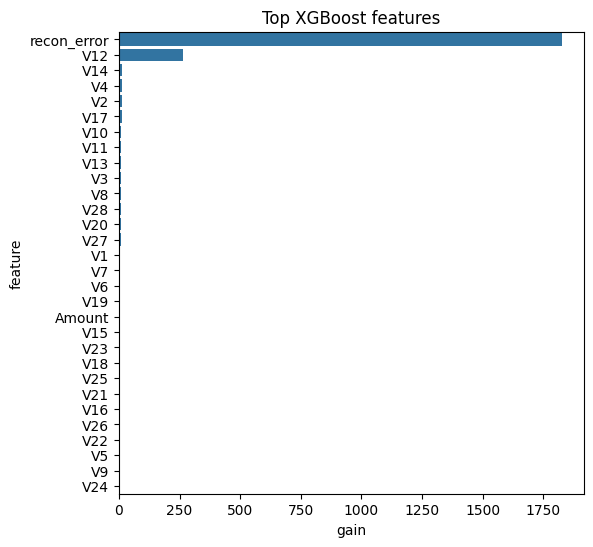

Saved transactions_with_scores.csv
All done. You now have: autoencoder_model.h5, scaler.save, xgb_model.json, transactions_with_scores.csv


In [14]:
# Cell 11: Evaluate XGBoost and save outputs
y_pred_prob = bst.predict(dtest)
y_pred = (y_pred_prob > 0.5).astype(int)

auc_val = roc_auc_score(y_test_xgb, y_pred_prob)
print("XGBoost AUC on test:", auc_val)

print("Classification report (XGBoost):")
print(classification_report(y_test_xgb, y_pred, digits=4))

cm = confusion_matrix(y_test_xgb, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (XGBoost)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

fpr, tpr, _ = roc_curve(y_test_xgb, y_pred_prob)
plt.figure()
plt.plot(fpr, tpr)
plt.title(f'XGBoost ROC (AUC={auc_val:.4f})')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

# Feature importance
feature_names = list(X_full.columns) + ['recon_error']
importance = bst.get_score(importance_type='gain')
imp_items = []
for k, v in importance.items():
    idx = int(k[1:])
    fname = feature_names[idx] if idx < len(feature_names) else f'f{idx}'
    imp_items.append((fname, v))
imp_df = pd.DataFrame(imp_items, columns=['feature','gain']).sort_values('gain', ascending=False).head(30)
print("Top features by gain:\n", imp_df)
plt.figure(figsize=(6,6))
sns.barplot(x='gain', y='feature', data=imp_df)
plt.title('Top XGBoost features')
plt.show()

# Save final dataset with recon error and predictions
# Append predicted probability to full dataset
full_probs = bst.predict(xgb.DMatrix(X_for_xgb))
df_with_scores['xgb_prob'] = full_probs
df_with_scores.to_csv('transactions_with_scores.csv', index=False)
print("Saved transactions_with_scores.csv")

print("All done. You now have: autoencoder_model.h5, scaler.save, xgb_model.json, transactions_with_scores.csv")